# API - *Application Programming Interface*

Um conjunto de regras que permitem a uma aplicação se comunicar com outra (*programmatically*) sem o conhecimento de como essa segunda foi implementada.

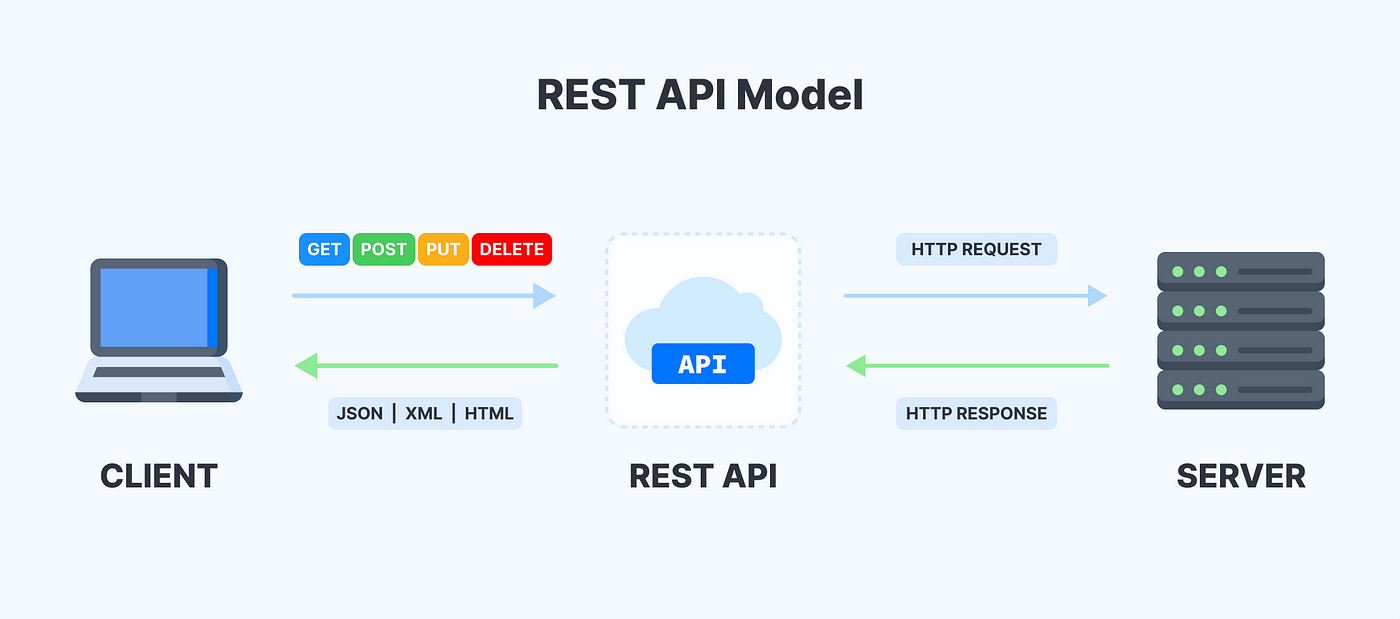

### Vantagens de utilizar APIs (em DS)

*   Autorização de acesso (Conformidade Legal e Ética);
*   Maior confiabilidade;
*   Dados estruturados;
*   Melhor manutenibilidade;
*   Maior eficiência e menor sobrecarga dos servidores.

### Desvantagens

* Limitações de acesso aos dados;
* Limitação das taxas de requisição;
* Complexidade de autenticação;
* Custo.

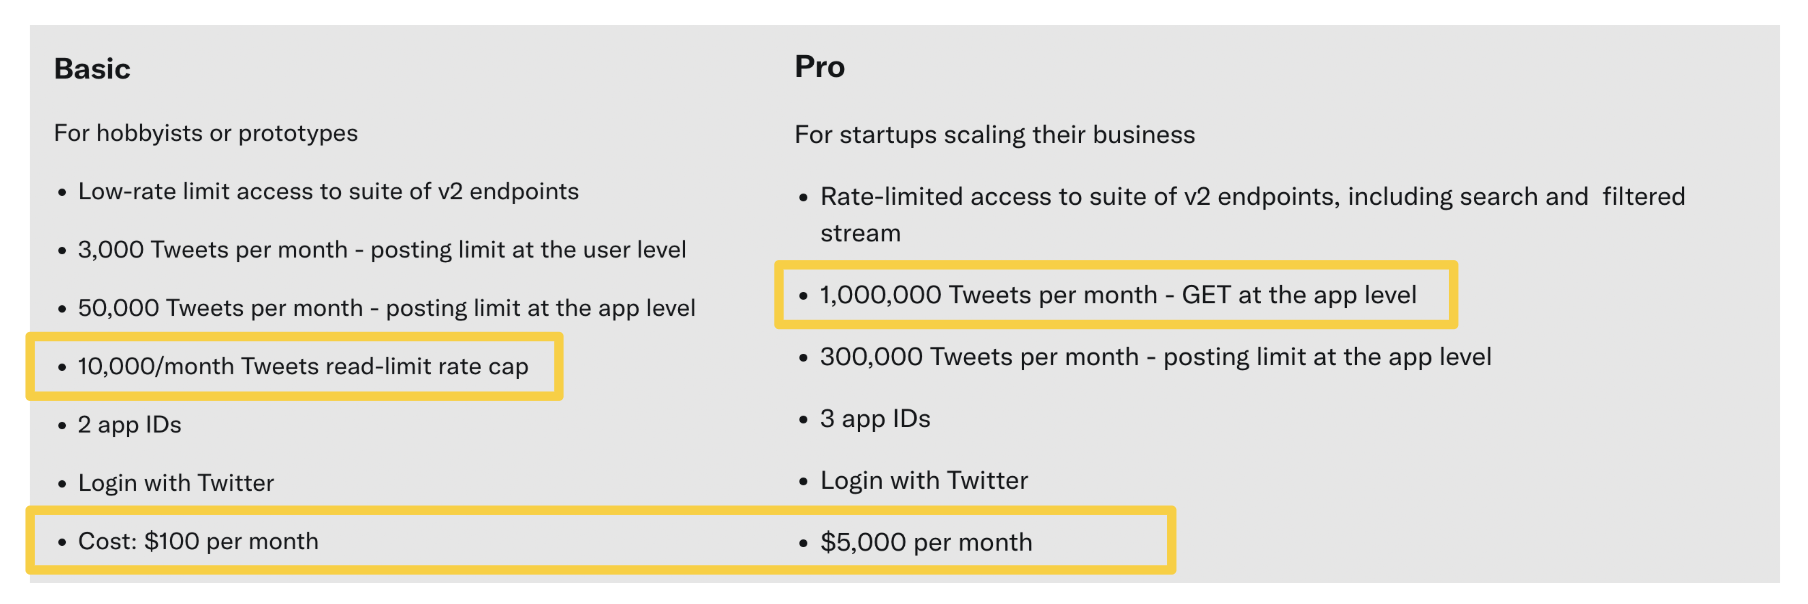

Twitter API: https://developer.twitter.com/en/docs/twitter-api

Telegram (Bot API and Client API): https://core.telegram.org/api

Coleção de APIs públicas (gratuitas): https://github.com/public-apis/public-apis

### Exemplo básico: CaaS (Cat as a Sevice)

In [ ]:
import requests

In [ ]:
r = requests.get('https://cataas.com/cat')
r

<Response [200]>

In [ ]:
r.status_code

200

In [ ]:
r.headers

{'Access-Control-Allow-Headers': 'X-Requested-With, Content-Type, Accept, Origin, Authorization', 'Access-Control-Allow-Methods': 'GET, POST, PUT, DELETE, OPTIONS', 'Access-Control-Allow-Origin': '*', 'Content-Length': '51445', 'Content-Type': 'image/jpeg', 'Date': 'Sun, 12 Oct 2025 14:49:23 GMT', 'Set-Cookie': '__Host-SESSION_ID=2dfa200a-d8d2-49db-8a28-f316ead66294; Path=/; Secure; HttpOnly; SameSite=Strict'}

In [ ]:
r.content

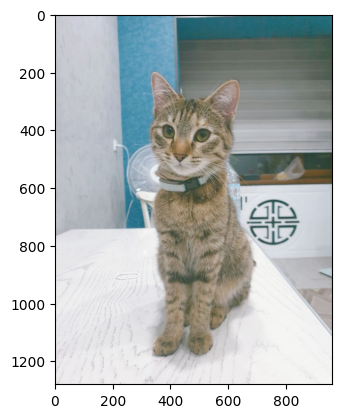

In [ ]:
import io
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(io.BytesIO(r.content))
plt.imshow(img)
plt.show()

In [ ]:
endpoint = 'https://cataas.com/cat/cute'
params = {
    'json': 'true',
}

r = requests.get(endpoint, params).json(); r

{'id': 'crOpMPGH3I9Zblv9',
 'tags': ['cute', 'sleepy'],
 'created_at': '2021-01-27T00:37:24.422Z',
 'url': 'https://cataas.com/cat/crOpMPGH3I9Zblv9?position=center',
 'mimetype': 'image/jpeg'}

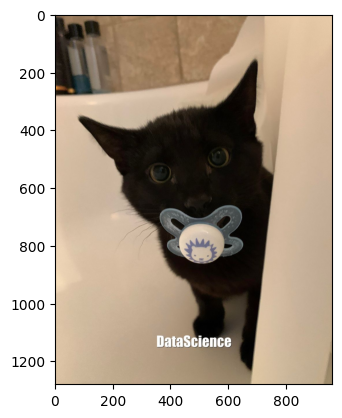

In [ ]:
endpoint = 'https://cataas.com/cat/says/DataScience'
r = requests.get(endpoint)
plt.imshow(Image.open(io.BytesIO(r.content)))
plt.show()

In [ ]:
# Free Dictionary API

version = "v2"
word = "cat"
r = requests.get(f'https://api.dictionaryapi.dev/api/{version}/entries/en/{word}')
r.json()

## Prática: Youtube API

Documentação: https://developers.google.com/youtube/v3?hl=pt-br

Para gerar sua chave: https://console.cloud.google.com/

In [ ]:
import requests
import pandas as pd

In [ ]:
YOUTUBE_API_KEY = "" # Sua chave de API aqui.

In [ ]:
url = "https://www.googleapis.com/youtube/v3/search"
params = {
  "key": YOUTUBE_API_KEY,
  "q": "vacina",
  "maxResults": 100,
  "part": "snippet"
}

In [ ]:
response = requests.get(url, params)

In [ ]:
data = response.json()

In [ ]:
data['pageInfo']['totalResults']

1000000

In [ ]:
data['items'][0]

{'kind': 'youtube#searchResult',
 'etag': 'kPlkBlYxePwIVt4TdKBLj4OSQ0Q',
 'id': {'kind': 'youtube#video', 'videoId': 'yY2bEUpaYDw'},
 'snippet': {'publishedAt': '2025-10-09T13:11:36Z',
  'channelId': 'UCpnjTqS1L_dB3c-2WG5DJ4g',
  'title': 'VACINA QUE TRANSFORMA DO PIMGO!',
  'description': 'Seja membro do canal e ganhe benefícios: https://www.youtube.com/@Pimgobr ————————— Contato Profissional ...',
  'thumbnails': {'default': {'url': 'https://i.ytimg.com/vi/yY2bEUpaYDw/default.jpg',
    'width': 120,
    'height': 90},
   'medium': {'url': 'https://i.ytimg.com/vi/yY2bEUpaYDw/mqdefault.jpg',
    'width': 320,
    'height': 180},
   'high': {'url': 'https://i.ytimg.com/vi/yY2bEUpaYDw/hqdefault.jpg',
    'width': 480,
    'height': 360}},
  'channelTitle': 'Pimgo',
  'liveBroadcastContent': 'none',
  'publishTime': '2025-10-09T13:11:36Z'}}

In [ ]:
titles = [item["snippet"]["title"] for item in data["items"]]

In [ ]:
from wordcloud import WordCloud

text = " ".join(titles)

wc = WordCloud().generate(text)

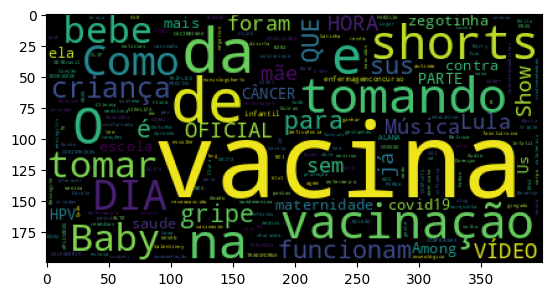

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(wc)
plt.show()

### Análise de discurso (Transcrições)

In [ ]:
!pip install youtube-transcript-api==0.6.1

In [ ]:
from youtube_transcript_api import YouTubeTranscriptApi, TranscriptsDisabled, NoTranscriptFound, TooManyRequests
from tqdm import tqdm

ids = [item["id"]["videoId"] for item in data["items"] if "videoId" in item["id"]]
transcricoes = ""

for id in tqdm(ids):
  try:
    t = YouTubeTranscriptApi.get_transcript(str(id), languages=['pt'])
    transcricoes += " ".join([seg['text'] for seg in t])
  except (NoTranscriptFound, TranscriptsDisabled):
    print(f"Transcrição indisponível para o vídeo {id}")
  except TooManyRequests:
      print(f"Muitas requisições — aguarde e tente novamente.")
  except Exception as e:
      print(f"Erro no video {id}: {e}")

### Análise de discurso (Descrições)

In [ ]:
descs = [item["snippet"].get("description", "") for item in data["items"] if "description" in item["snippet"]]

In [ ]:
# preprocessing
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-záéíóúãõâêîôûç0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

descriptions = [clean_text(d) for d in descs]

In [ ]:
# td-idf :)
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_pt = list(set(stopwords.words("portuguese")))

vectorizer = TfidfVectorizer(max_features=1000, stop_words=stop_pt)

X = vectorizer.fit_transform(descriptions)
terms = vectorizer.get_feature_names_out()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# frequência média dos termos
import numpy as np

avg_tfidf = np.asarray(X.mean(axis=0)).ravel()
freq = {terms[i]: float(avg_tfidf[i]) for i in range(len(terms))}

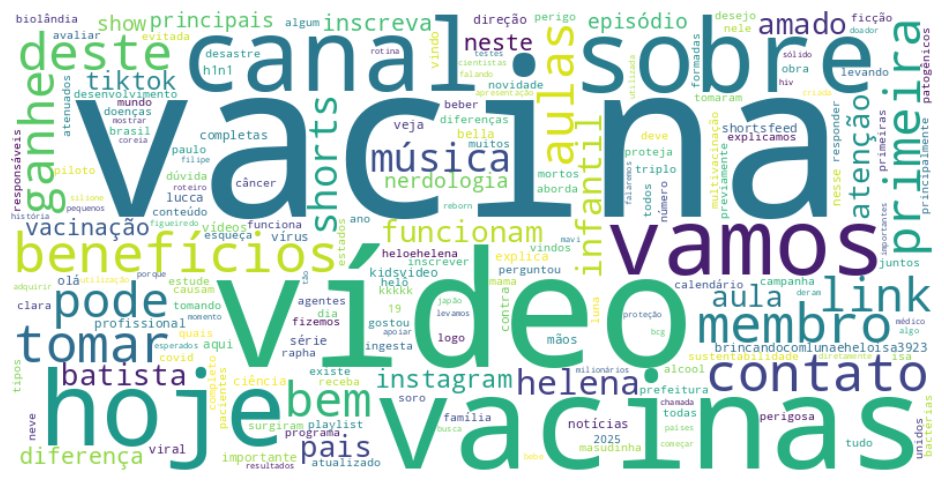

In [ ]:
# word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color="white")
wc.generate_from_frequencies(freq)
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()